# Makroökonomische Zeitreihenmodellierung: Phillips-Kurve

Dieses Projekt untersucht den Zusammenhang zwischen Inflation und Arbeitslosigkeit in den USA anhand der Phillips-Kurve.

Die Analyse basiert auf historischen US-Daten der Federal Reserve Economic Data (FRED) für den Zeitraum 1950 bis 1970.

In [2]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas_datareader.data as pdr

## Datenbeschaffung

Für die Analyse werden folgende makroökonomische Zeitreihen verwendet:

- Verbraucherpreisindex (CPI) zur Berechnung der Inflationsrate
- Arbeitslosenquote (Unemployment Rate)

Die Daten werden direkt aus der FRED-Datenbank der Federal Reserve geladen.

In [3]:
# Daten abrufen (1950 bis 1970)
cpi = pdr.DataReader("CPIAUCSL", "fred", start="1950-01-01", end="1970-01-01")
unemp = pdr.DataReader("UNRATE", "fred", start="1950-01-01", end="1970-01-01")

# Inflation(%-Änderung über 12 Monate)
cpi["Inflation"] = cpi["CPIAUCSL"].pct_change(12) * 100

# Zusammenführen
data = pd.concat([cpi["Inflation"], unemp], axis=1).dropna()
data.columns = ["Inflation", "Unemployment"]

data.head()

,Inflation,Unemployment
DATE,,
1951-01-01,7.954062,3.7
1951-02-01,9.402795,3.4
1951-03-01,9.475465,3.4
1951-04-01,9.598309,3.1
1951-05-01,9.339504,3.0


Die Inflationsrate wird als prozentuale Veränderung des Verbraucherpreisindex gegenüber dem Vorjahresmonat berechnet.


## Explorative Analyse

Vor der Regressionsanalyse werden die makroökonomischen Variablen visuell betrachtet, um erste Zusammenhänge und Entwicklungen im Zeitverlauf zu identifizieren.

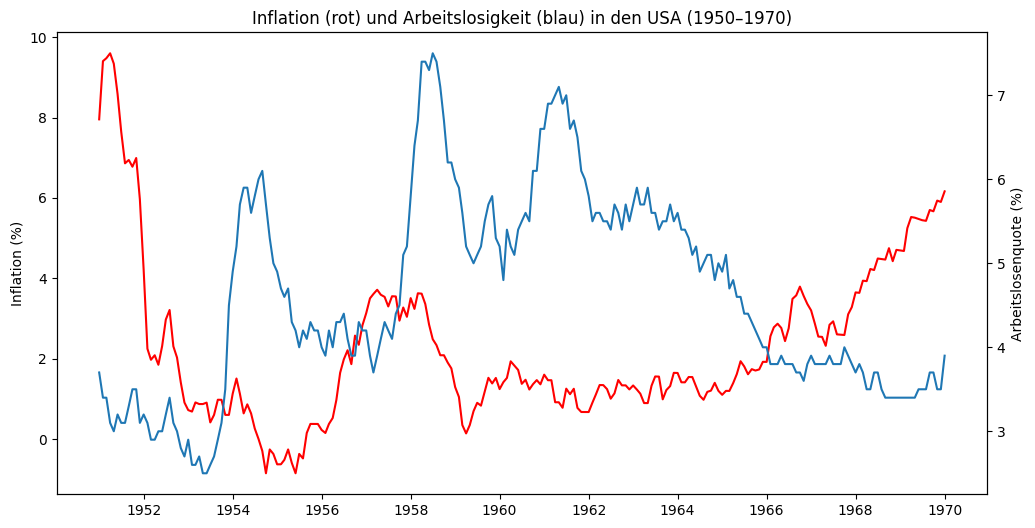

In [6]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(
    data.index,
    data["Inflation"],
    label="Inflation",
    c="red"
)

ax1.set_ylabel("Inflation (%)")

ax2 = ax1.twinx()

ax2.plot(
    data.index,
    data["Unemployment"],
    label="Arbeitslosigkeit"
)

ax2.set_ylabel("Arbeitslosenquote (%)")

plt.title("Inflation (rot) und Arbeitslosigkeit (blau) in den USA (1950–1970)")

plt.show()

## OLS-Regressionsmodell

Zur Untersuchung des Zusammenhangs zwischen Inflation und Arbeitslosigkeit wird ein lineares OLS-Regressionsmodell (Ordinary Least Squares) verwendet.

Die Arbeitslosenquote dient dabei als erklärende Variable für die Inflationsrate.

                            OLS Regression Results                            
Dep. Variable:              Inflation   R-squared:                       0.175
Model:                            OLS   Adj. R-squared:                  0.172
Method:                 Least Squares   F-statistic:                     48.28
Date:                Wed, 29 Oct 2025   Prob (F-statistic):           3.86e-11
Time:                        10:41:47   Log-Likelihood:                -460.57
No. Observations:                 229   AIC:                             925.1
Df Residuals:                     227   BIC:                             932.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            5.5066      0.480     11.482   

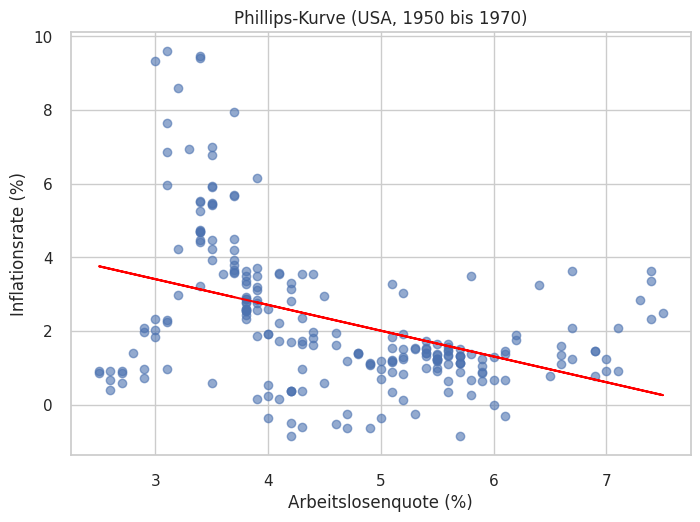

In [ ]:
# Regression
X = sm.add_constant(data["Unemployment"])
model = sm.OLS(data["Inflation"], X).fit()

print(model.summary())

# Plot
plt.scatter(data["Unemployment"], data["Inflation"], alpha=0.6)
plt.plot(data["Unemployment"], model.predict(X), color="red")
plt.xlabel("Arbeitslosenquote (%)")
plt.ylabel("Inflationsrate (%)")
plt.title("Phillips-Kurve (USA, 1950 bis 1970)")
plt.show()

Die Visualisierung zeigt den geschätzten linearen Zusammenhang zwischen Inflation und Arbeitslosigkeit.

Die Regressionsgerade deutet auf eine tendenziell negative Beziehung hin, wobei die Streuung der Datenpunkte gleichzeitig verdeutlicht, dass makroökonomische Zusammenhänge nicht vollständig durch einfache lineare Modelle erklärt werden können.